<a href="https://colab.research.google.com/github/Arxivory/TagInit-ML-Core/blob/main/taginit_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tag-Init: The ML Pipeline**
*Neural Solvers for Street-Level Heat Mapping in Metro Manila*

### **The Urban Thermal Problematic**
The Urban Heat Island (UHI) effect presents a critical challenge for dense tropical metropolises. While thermal infrared (TIR) sensors on satellites like Landsat 8 provide essential surface temperature data, they suffer from a significant spatial-spectral trade-off. At a $100\text{m}$ resolution, street-level thermal variances—such as the cooling effect of a single pocket park or the extreme heat of a galvanized iron (G.I.) roof—are lost to pixel averaging.


Tag-init addresses this "spatial blindness" by implementing a Physics-Informed Neural Network (PINN) to perform thermal super-resolution, upscaling $100\text{m}$ thermal data to a $10\text{m}$ granular scale using $10\text{m}$ multi-spectral guidance (Sentinel-2).

## **Data Acquisition & Preprocessing**

**Project Setup**

In [ ]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
ee.Authenticate()
ee.Initialize(project='put-your-project-id-here')

**Data Fusion and Pre-processing**

For this project, I utilized Google Earth Engine (GEE) to synthesize a multi-temporal median composite for the "Tag-init" months (March–May). This minimizes cloud artifacts and captures the peak thermal stress period.Predictor ($X$):
- Sentinel-2 RGB/NIR bands at $10\text{m}$ resolution.Target ($Y$):
- Landsat-8 Thermal Infrared (TIRS) band, resampled to $10\text{m}$.


In [ ]:
def get_urban_heat_data(region, start_date, end_date):
    s2_col = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(region) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))

    l8_col = ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA") \
        .filterBounds(region) \
        .filterDate(start_date, end_date) \
        .sort('CLOUD_COVER')

    print(f"Sentinel images: {s2_col.size().getInfo()}")
    print(f"Landsat images: {l8_col.size().getInfo()}")

    rgb_img = s2_col.median().select(['B4', 'B3', 'B2']).divide(10000).clip(region)

    thermal_img = l8_col.first().select('B10').clip(region)

    temp_celsius = thermal_img.subtract(273.15)

    temp_resampled = temp_celsius.resample('bicubic').reproject(
        crs=rgb_img.projection(), scale=10
    )

    return rgb_img, temp_resampled

In [ ]:
def get_historical_tag_init_data(region, start_year, end_year):
    all_rgb = []
    all_temp = []

    for year in range(start_year, end_year + 1):
        print(f"Processing Tag-init {year}...")
        start_date = f'{year}-03-01'
        end_date = f'{year}-05-31'

        rgb_img, temp_img = get_urban_heat_data(region, start_date, end_date)

        if rgb_img and temp_img:
            all_rgb.append(rgb_img)
            all_temp.append(temp_img)
    rgb_col = ee.ImageCollection(all_rgb)
    temp_col = ee.ImageCollection(all_temp)

    rgb_final = rgb_col.median()
    temp_final = temp_col.median()

    return rgb_final, temp_final

**Visualizing the Ground Truth**

In [ ]:
manila_aoi = ee.Geometry.Rectangle([120.98, 14.55, 121.08, 14.65]) # Focus on Makati/Manila

rgb, temp = get_historical_tag_init_data(manila_aoi, 2020, 2025)

stats = temp.reduceRegion(reducer=ee.Reducer.minMax(), geometry=manila_aoi, scale=30, bestEffort=True).getInfo()
print("New Stats:", stats)

t_min = stats['B10_min']
t_max = stats['B10_max']

Processing Tag-init 2020...
Sentinel images: 15
Landsat images: 6
Processing Tag-init 2021...
Sentinel images: 11
Landsat images: 5
Processing Tag-init 2022...
Sentinel images: 10
Landsat images: 6
Processing Tag-init 2023...
Sentinel images: 11
Landsat images: 6
Processing Tag-init 2024...
Sentinel images: 12
Landsat images: 6
Processing Tag-init 2025...
Sentinel images: 11
Landsat images: 6
New Stats: {'B10_max': 39.78009800127551, 'B10_min': 15.307199061411467}


In [ ]:
Map = geemap.Map()
Map.centerObject(manila_aoi, 14)

Map.addLayer(rgb, {'min': 0, 'max': 0.3}, 'Base City Map')
Map.addLayer(temp, {'min': t_min, 'max': t_max, 'palette': ['blue', 'yellow', 'red']}, 'Heat Map Overlay', True, 0.6)
display(Map)

## **Data Engineering: The Sliding Window Slicer**
To train the model on large-scale urban imagery, I implemented a Sliding Window Patch Slicer.
- Patch Size: $256 \times 256$ pixels.
- Stride: $64$ (providing a $75\%$ overlap).

This technique significantly increases the training dataset size and provides the model with multiple spatial views of the same urban features, improving generalization across different districts of Metro Manila.

**Data Slicer**

In [ ]:
def create_patches(rgb_data, temp_data, patch_size=256, stride=128):
    patches_x = []
    patches_y = []

    c, h, w = rgb_data.shape

    for i in range(0, h - patch_size, stride):
        for j in range(0, w - patch_size, stride):

            patch_rgb = rgb_data[:, i:i+patch_size, j:j+patch_size]
            patch_temp = temp_data[:, i:i+patch_size, j:j+patch_size]

            if not np.isnan(patch_rgb).any() and not np.isnan(patch_temp).any():
                patches_x.append(patch_rgb)
                patches_y.append(patch_temp)

    return np.array(patches_x), np.array(patches_y)

In [ ]:
def gather_all_patches(region, start_year, end_year):
    final_x = []
    final_y = []

    for year in range(start_year, end_year + 1):
        print(f"--- Slicing Year {year} ---")
        rgb_img, temp_img = get_urban_heat_data(region, f'{year}-03-01', f'{year}-05-31')

        rgb_arr = geemap.ee_to_numpy(rgb_img, region=region, bands=['B4', 'B3', 'B2'], scale=10)
        temp_arr = geemap.ee_to_numpy(temp_img, region=region, bands=['B10'], scale=10)

        x_patches, y_patches = create_patches(
            rgb_arr.transpose(2,0,1),
            temp_arr.transpose(2,0,1),
            patch_size=256,
            stride=64
        )

        final_x.extend(x_patches)
        final_y.extend(y_patches)

    return np.array(final_x), np.array(final_y)

X_train, y_train = gather_all_patches(manila_aoi, 2021, 2025)
print(f"New Total Patches: {len(X_train)}")

--- Slicing Year 2021 ---
Sentinel images: 11
Landsat images: 5
--- Slicing Year 2022 ---
Sentinel images: 10
Landsat images: 6
--- Slicing Year 2023 ---
Sentinel images: 11
Landsat images: 6
--- Slicing Year 2024 ---
Sentinel images: 12
Landsat images: 6
--- Slicing Year 2025 ---
Sentinel images: 11
Landsat images: 6
New Total Patches: 980


## **Architectural Design: The Spatial Encoder-Decoder**
The transition from an MLP (Multi-Layer Perceptron) (my previous project) to a U-Net architecture represents a shift from point-wise estimation to Spatial Contextual Reasoning.

### **The U-Net Backbone**
The model architecture employs a symmetrical encoder-decoder structure with Skip Connections.

- Encoder: Gradually reduces spatial dimensions while increasing feature depth, capturing high-level urban morphology (e.g., "this area is a dense residential block").

- Decoder: Upsamples these features back to the original resolution.

- Skip Connections: Directly concatenate fine-grained textural features from the encoder to the decoder, ensuring that building edges and road narrowness are preserved in the final heat map.

**Import**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

**Double Convolutional Block**

In [ ]:
class DoubleConv(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.double_conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.double_conv(x)

**U-Net Class**

In [ ]:
class UrbanHeatNN(nn.Module):
  def __init__(self, n_channels=3, n_classes=1):
    super(UrbanHeatNN, self).__init__()

    self.inc = DoubleConv(n_channels, 64)
    self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
    self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
    self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

    self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
    self.conv_up1 = DoubleConv(512, 256)

    self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.conv_up2 = DoubleConv(256, 128)

    self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    self.conv_up3 = DoubleConv(128, 64)

    self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

  def forward(self, x):
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)

    x = self.up1(x4)
    x = torch.cat([x, x3], dim=1)
    x = self.conv_up1(x)

    x = self.up2(x)
    x = torch.cat([x, x2], dim=1)
    x = self.conv_up2(x)

    x = self.up3(x)
    x = torch.cat([x, x1], dim=1)
    x = self.conv_up3(x)

    return self.outc(x)

## **The Governing Physics: Laplacian Regularization**
Traditional Computer Vision models often produce "hallucinations"—visually plausible but physically impossible pixel values. To prevent this, Tag-init incorporates the Steady-State Heat Equation.
1. The Heat Diffusion ConstraintIn a steady-state urban environment, the distribution of temperature $T$ across a surface is governed by the Laplacian operator:$$\nabla^2 T = \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \approx 0$$This equation implies that in the absence of a concentrated source/sink, the temperature of a pixel should be the average of its neighbors.
2. The Laplacian KernelIn implementation, we use a discrete $3 \times 3$ Laplacian kernel $\mathbf{K}$ to calculate the spatial second derivative of the predicted heat map:$$\mathbf{K} = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$The result of this convolution $(\hat{y} * \mathbf{K})$ identifies areas where the heat distribution is physically discontinuous, allowing the model to self-correct during backpropagation.

### **The Objective Function**
The training process is guided by a composite loss function that balances empirical accuracy with physical validity:$$\mathcal{L}_{total} = \alpha \underbrace{\text{MSE}(\hat{y}, y)}_{Data\ Loss} + \beta \underbrace{||\nabla^2 \hat{y}||_1}_{Physics\ Loss}$$
- $\text{MSE}(\hat{y}, y)$: Ensures the model matches the ground-truth satellite data.
- $||\nabla^2 \hat{y}||_1$: Acts as a "Physical Regularizer," smoothing out artifacts and ensuring that heat flows logically across the urban fabric.

In [ ]:
class PhysicsInformedLoss(nn.Module):
  def __init__(self, lambda_physics=0.01):
    super(PhysicsInformedLoss, self).__init__()
    self.lambda_physics = lambda_physics

    self.laplacian_kernel = torch.tensor(
        [[[[0, 1, 0],
          [1, -4, 1],
          [0, 1, 0]]]], dtype=torch.float32
    )

  def forward(self, pred, target):
    loss_mse = F.mse_loss(pred, target)

    if pred.is_cuda:
      self.laplacian_kernel = self.laplacian_kernel.to(pred.device)

    physics_residual = F.conv2d(pred, self.laplacian_kernel, padding=1)
    loss_physics = torch.mean(torch.abs(physics_residual))

    total_loss = loss_mse + (self.lambda_physics * loss_physics)

    return total_loss, loss_mse, loss_physics

**Testing**

In [ ]:
criterion = PhysicsInformedLoss(lambda_physics=0.1)
dummy_pred = torch.randn(1, 1, 256, 256, requires_grad=True)
dummy_target = torch.ones(1, 1, 256, 256)

total, mse, phys = criterion(dummy_pred, dummy_target)

print(f"Total Loss: {total.item():.4f}")
print(f"MSE (Data) Part: {mse.item():.4f}")
print(f"Physics Part: {phys.item():.4f}")

Total Loss: 2.3552
MSE (Data) Part: 1.9986
Physics Part: 3.5659


## **Model Training**

**Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

To ensure numerical stability within the neural network, we apply a linear normalization to the raw Kelvin values:$$T_{norm} = \frac{T_{raw} - T_{min}}{T_{max} - T_{min}}$$Where $T \in [0, 1]$. This mapped space allows the model to learn relative thermal gradients effectively across diverse urban materials.

In [ ]:

X_scaled = X_train / X_train.max()

y_scaled = (y_train - t_min) / (t_max - t_min)

X_tensor = torch.from_numpy(X_scaled).float()
y_tensor = torch.from_numpy(y_scaled).float()

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train_split, y_train_split)
val_dataset = TensorDataset(X_val_split, y_val_split)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Training samples: {len(X_train_split)}")
print(f"Validation samples: {len(X_val_split)}")

Training samples: 784
Validation samples: 196


**Training Loop**

In [ ]:
import torch.optim as optim

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UrbanHeatNN().to(device)
criterion = PhysicsInformedLoss(lambda_physics=0.05)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 50
train_losses = []

In [ ]:
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for images, targets in train_loader:
    images, targets = images.to(device), targets.to(device)

    outputs = model(images)

    total_loss, mse_part, phys_part = criterion(outputs, targets)

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    running_loss += total_loss.item()

  epoch_loss = running_loss / len(train_loader)
  train_losses.append(epoch_loss)

  print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f} (MSE: {mse_part:.6f}, Phys: {phys_part:.6f})")

print("Training Complete!")

Epoch [1/50] - Loss: 0.221865 (MSE: 0.084759, Phys: 0.149838)
Epoch [2/50] - Loss: 0.094898 (MSE: 0.074807, Phys: 0.092306)
Epoch [3/50] - Loss: 0.085123 (MSE: 0.075501, Phys: 0.077333)
Epoch [4/50] - Loss: 0.082760 (MSE: 0.073362, Phys: 0.073733)
Epoch [5/50] - Loss: 0.074798 (MSE: 0.056851, Phys: 0.064396)
Epoch [6/50] - Loss: 0.066782 (MSE: 0.057734, Phys: 0.058657)
Epoch [7/50] - Loss: 0.060119 (MSE: 0.048019, Phys: 0.059838)
Epoch [8/50] - Loss: 0.054142 (MSE: 0.044976, Phys: 0.052522)
Epoch [9/50] - Loss: 0.046936 (MSE: 0.033918, Phys: 0.053278)
Epoch [10/50] - Loss: 0.042347 (MSE: 0.048532, Phys: 0.047313)
Epoch [11/50] - Loss: 0.037885 (MSE: 0.024380, Phys: 0.048631)
Epoch [12/50] - Loss: 0.025057 (MSE: 0.019891, Phys: 0.047216)
Epoch [13/50] - Loss: 0.025470 (MSE: 0.013395, Phys: 0.042095)
Epoch [14/50] - Loss: 0.020146 (MSE: 0.012336, Phys: 0.037322)
Epoch [15/50] - Loss: 0.017875 (MSE: 0.016160, Phys: 0.038876)
Epoch [16/50] - Loss: 0.016633 (MSE: 0.008126, Phys: 0.038078)
E

## **Model Evaluation**

In [ ]:
import matplotlib.pyplot as plt

def evaluate_and_plot(model, dataloader, num_samples=3):
    model.eval()
    images, targets = next(iter(dataloader))
    images, targets = images.to(device), targets.to(device)

    with torch.no_grad():
        preds = model(images)

    images = images.cpu().numpy()
    targets = targets.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(images[i].transpose(1, 2, 0))
        plt.title("Satellite RGB")
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 2)
        true_temp = targets[i][0] * (t_max - t_min) + t_min
        plt.imshow(true_temp, cmap='inferno')
        plt.title("Actual Heat (Landsat)")
        plt.colorbar(label='°C')
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 3)
        pred_temp = preds[i][0] * (t_max - t_min) + t_min
        plt.imshow(pred_temp, cmap='inferno')
        plt.title("Predicted Heat (U-Net)")
        plt.colorbar(label='°C')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

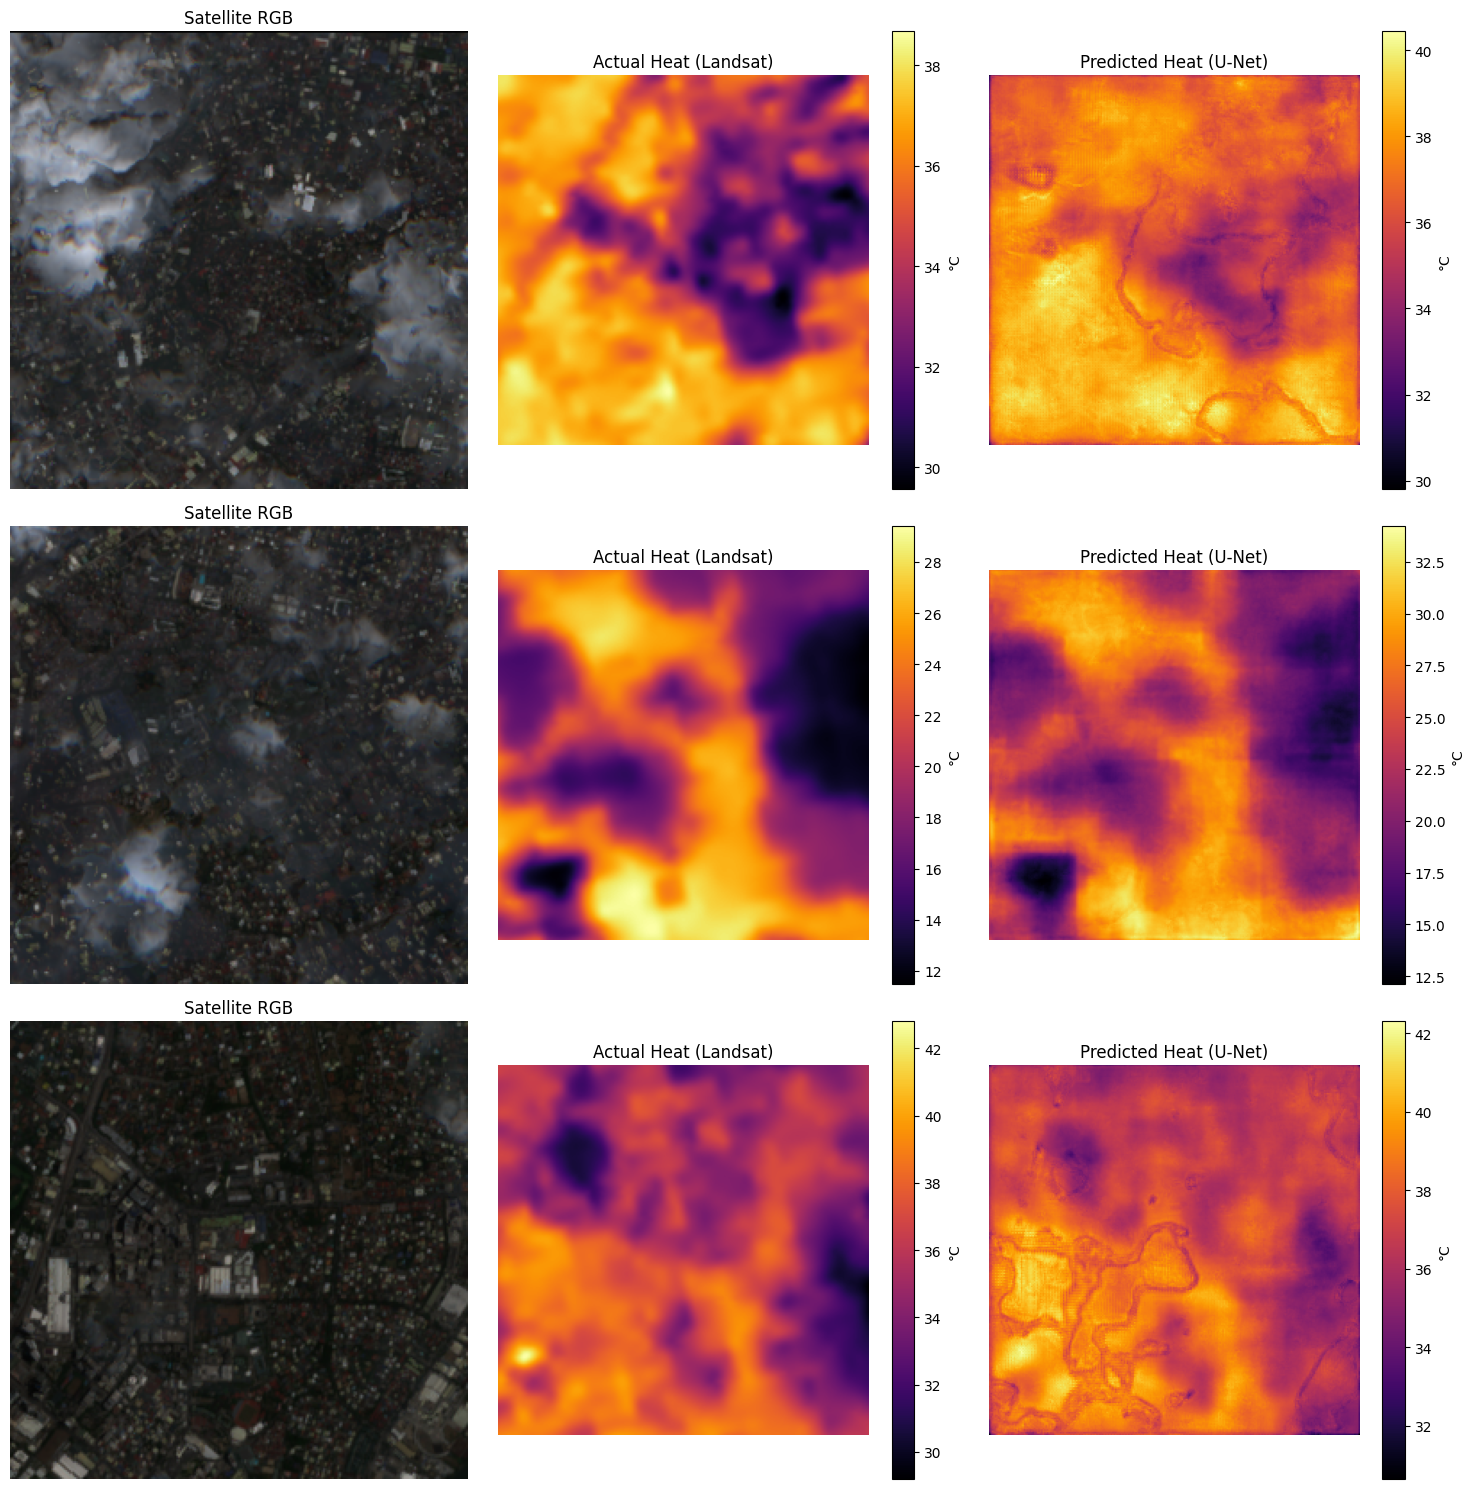

In [ ]:
evaluate_and_plot(model, val_loader)

## **Synthesis and Deployment Path**
The finalized pipeline produces a high-fidelity thermal map that preserves the structural integrity of the city. For mobile deployment (soon), the model undergoes 8-bit Static Quantization, converting weights from Float32 to Int8. This reduces the memory footprint by $\sim 75\%$ while maintaining the physical consistency established during the research phase, enabling real-time thermal visualization on edge devices.

**Colab Export**

In [ ]:
torch.save(model.state_dict(), 'urban_heat_unet_weights.pth')

model.eval()
example_input = torch.rand(1, 3, 256, 256).to(device)
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("urban_heat_model_mobile.pt")

print("Model Saved!")

Model Saved!


**Google Drive Export**

In [44]:
from google.colab import drive
drive.flush_and_unmount('/content/drive')
print("Google Drive unmounted.")

Drive not mounted, so nothing to flush and unmount.
Google Drive unmounted.


In [46]:
drive.mount('/content/drive')

Mounted at /content/drive


In [47]:
import os

drive_path = '/content/drive/MyDrive/UrbanHeatModel'

os.makedirs(drive_path, exist_ok=True)

print(f"Google Drive directory '{drive_path}' ensured.")


Google Drive directory '/content/drive/MyDrive/UrbanHeatModel' ensured.


In [48]:
torch.save(model.state_dict(), os.path.join(drive_path, 'urban_heat_unet_weights.pth'))

model.eval()
example_input = torch.rand(1, 3, 256, 256).to(device)
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save(os.path.join(drive_path, "urban_heat_model_mobile.pt"))

print("Model Saved to Google Drive!")

Model Saved to Google Drive!
